In [2]:
#Könyvtár behívása
import pandas as pd

In [3]:
#Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
ah = pd.read_csv(root, sep=';')

In [4]:
print(f"Sorok: {len(ah)}")
print(f"Változók (oszlopok száma): {len(ah.columns)}")
print(ah.head())
print(ah.describe())
print(ah['job'].value_counts())
print(ah['balance'].describe())

Sorok: 45211
Változók (oszlopok száma): 17
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
                age        balance           day      duration      

In [5]:
# 1. Log-transzformáció ferde változókhoz
import numpy as np
ah['balance_log'] = np.log1p(ah['balance'])  # +1 hogy ne legyen log(0)
ah['duration_log'] = np.log1p(ah['duration'])

# 2. Standardizálás (klaszterezés előtt mindig!)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_cols = ah.select_dtypes(include=['int64']).columns.tolist()
ah_scaled = scaler.fit_transform(ah[numerical_cols])

# 3. Outlier kezelés (IQR módszer)
Q1 = ah['balance'].quantile(0.25)
Q3 = ah['balance'].quantile(0.75)
IQR = Q3 - Q1

print(ah['balance_log'])
print(ah['duration_log'])

0        7.670429
1        3.401197
2        1.098612
3        7.317876
4        0.693147
           ...   
45206    6.716595
45207    7.455877
45208    8.651025
45209    6.505784
45210    7.996990
Name: balance_log, Length: 45211, dtype: float64
0        5.568345
1        5.023881
2        4.343805
3        4.532599
4        5.293305
           ...   
45206    6.885510
45207    6.124683
45208    7.028201
45209    6.232448
45210    5.891644
Name: duration_log, Length: 45211, dtype: float64


c:\Users\Balázs\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Balázs\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
# Winsorization (1-99 percentilis)
from scipy.stats.mstats import winsorize
ah['balance_win'] = winsorize(ah['balance'], limits=[0.01, 0.01])
ah['duration_win'] = winsorize(ah['duration'], limits=[0.01, 0.01])

In [7]:
ah.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,balance_log,duration_log,balance_win,duration_win
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,7.670429,5.568345,2143,261
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,151,1,-1,0,unknown,no,3.401197,5.023881,29,151
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,76,1,-1,0,unknown,no,1.098612,4.343805,2,76
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,92,1,-1,0,unknown,no,7.317876,4.532599,1506,92
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,198,1,-1,0,unknown,no,0.693147,5.293305,1,198


In [8]:
from sklearn.cluster import KMeans


#standardizálás
X = ah[['age', 'balance', 'duration']].copy()
X_scaled = StandardScaler().fit_transform(X)

#kmeans algoritmus létrehozása
kmeans = KMeans(n_clusters=5, random_state=42)
ah['Klaszterközéppont'] = kmeans.fit_predict(X_scaled)

cluster_summary = ah.groupby('Klaszterközéppont').agg({
    'age': 'mean',
    'balance': 'mean',
    'duration':'count'
}).rename(columns={'age': 'átlag kor',
                   'balance': 'átlag egyenleg',
                   'duration':'ügyfelek száma'})

print(cluster_summary)

print("\n" + "="*50)
print("ÖSSZESÍTETT STATISZTIKÁK:")
print(f"Átlagos kor: {ah['age'].mean():.2f} év")
print(f"Átlagos egyenleg: {ah['balance'].mean():.2f} €")
print(f"Összes ügyfél: {len(ah)}")
print("="*50)

cluster_summary_combined = ah.groupby('Klaszterközéppont').agg({
    'age': ['mean', 'std'],
    'balance': ['mean', 'std'],
    'duration': 'count'
})

# Kombinált formátum: "átlag (±szórás)"
cluster_summary_formatted = pd.DataFrame({
    'Életkor': cluster_summary_combined['age'].apply(lambda x: f"{x['mean']:.2f} (±{x['std']:.1f})", axis=1),
    'Egyenleg': cluster_summary_combined['balance'].apply(lambda x: f"{x['mean']:.2f} (±{x['std']:.0f})", axis=1),
    'Ügyfelek száma': cluster_summary_combined['duration']['count']
})

print(cluster_summary_formatted)

                   átlag kor  átlag egyenleg  ügyfelek száma
Klaszterközéppont                                           
0                  33.960489      680.797063           23968
1                  52.510249      922.891946           14391
2                  42.395137     8033.954407            2632
3                  39.831166     1114.210855            3998
4                  46.387387    28788.364865             222

ÖSSZESÍTETT STATISZTIKÁK:
Átlagos kor: 40.94 év
Átlagos egyenleg: 1362.27 €
Összes ügyfél: 45211
                         Életkor           Egyenleg  Ügyfelek száma
Klaszterközéppont                                                  
0                   33.96 (±5.1)      680.80 (±984)           23968
1                   52.51 (±7.0)     922.89 (±1221)           14391
2                  42.40 (±10.0)    8033.95 (±3152)            2632
3                   39.83 (±9.6)    1114.21 (±1648)            3998
4                  46.39 (±12.3)  28788.36 (±13314)             222

In [9]:
#winsorization-nel végzett klaszterezés
#standardizálás
X = ah[['age', 'balance_win', 'duration_win']].copy()
X_scaled = StandardScaler().fit_transform(X)

#kmeans algoritmus létrehozása
kmeans = KMeans(n_clusters=5, random_state=42)
ah['Klaszterközéppont'] = kmeans.fit_predict(X_scaled)

cluster_summary = ah.groupby('Klaszterközéppont').agg({
    'age': 'mean',
    'balance': 'mean',
    'duration':'count'
}).rename(columns={'age': 'átlag kor',
                   'balance': 'átlag egyenleg',
                   'duration':'ügyfelek száma'})

print(cluster_summary)

print("\n" + "="*50)
print("ÖSSZESÍTETT STATISZTIKÁK:")
print(f"Átlagos kor: {ah['age'].mean():.2f} év")
print(f"Átlagos egyenleg: {ah['balance'].mean():.2f} €")
print(f"Összes ügyfél: {len(ah)}")
print("="*50)

cluster_summary_combined = ah.groupby('Klaszterközéppont').agg({
    'age': ['mean', 'std'],
    'balance': ['mean', 'std'],
    'duration': 'count'
})

# Kombinált formátum: "átlag (±szórás)"
cluster_summary_formatted = pd.DataFrame({
    'Életkor': cluster_summary_combined['age'].apply(lambda x: f"{x['mean']:.2f} (±{x['std']:.1f})", axis=1),
    'Egyenleg': cluster_summary_combined['balance'].apply(lambda x: f"{x['mean']:.2f} (±{x['std']:.0f})", axis=1),
    'Ügyfelek száma': cluster_summary_combined['duration']['count']
})

print(cluster_summary_formatted)

                   átlag kor  átlag egyenleg  ügyfelek száma
Klaszterközéppont                                           
0                  34.138001      659.532923           19181
1                  42.572759     1204.840124            2577
2                  43.147079     9693.382476            2876
3                  52.726289      913.642194           13675
4                  34.936685      791.376847            6902

ÖSSZESÍTETT STATISZTIKÁK:
Átlagos kor: 40.94 év
Átlagos egyenleg: 1362.27 €
Összes ügyfél: 45211
                         Életkor         Egyenleg  Ügyfelek száma
Klaszterközéppont                                                
0                   34.14 (±5.1)    659.53 (±973)           19181
1                  42.57 (±10.8)  1204.84 (±1649)            2577
2                  43.15 (±10.7)  9693.38 (±7283)            2876
3                   52.73 (±6.9)   913.64 (±1185)           13675
4                   34.94 (±6.1)   791.38 (±1081)            6902


In [10]:
import numpy as np

# 1. Ellenőrizd a negatív értékeket
print("Balance negatív értékek:", (ah['balance'] < 0).sum())
print("Duration negatív értékek:", (ah['duration'] < 0).sum())

# 2. Ellenőrizd a min/max értékeket
print("\nBalance min/max:", ah['balance'].min(), ah['balance'].max())
print("Duration min/max:", ah['duration'].min(), ah['duration'].max())

# 3. Log-transzformáció BIZTONSÁGOSAN
# Először klippeld az értékeket, hogy ne legyenek negatívak
ah['balance_clipped'] = ah['balance'].clip(lower=0)
ah['duration_clipped'] = ah['duration'].clip(lower=0)

# Most log-transzformáció
ah['balance_log'] = np.log1p(ah['balance_clipped'])
ah['duration_log'] = np.log1p(ah['duration_clipped'])

# 4. Ellenőrizd, hogy nincs-e inf vagy nan
print("\nBalance_log inf/nan:", np.isinf(ah['balance_log']).sum(), np.isnan(ah['balance_log']).sum())
print("Duration_log inf/nan:", np.isinf(ah['duration_log']).sum(), np.isnan(ah['duration_log']).sum())

# 5. Klaszterezés
X = ah[['age', 'balance_log', 'duration_log']].copy()

# Inf és NaN értékek eltávolítása
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
ah['Klaszterközéppont'] = kmeans.fit_predict(X_scaled)

print("="*70)

cluster_summary_combined = ah.groupby('Klaszterközéppont').agg({
    'age': ['mean', 'std'],
    'balance': ['mean', 'std'],
    'duration': 'count'
})

# Kombinált formátum: "átlag (±szórás)"
cluster_summary_formatted = pd.DataFrame({
    'Életkor': cluster_summary_combined['age'].apply(lambda x: f"{x['mean']:.1f} (±{x['std']:.1f})", axis=1),
    'Egyenleg': cluster_summary_combined['balance'].apply(lambda x: f"{x['mean']:.0f} (±{x['std']:.0f})", axis=1),
    'Ügyfelek száma': cluster_summary_combined['duration']['count']
})

print(cluster_summary_formatted)

Balance negatív értékek: 3766
Duration negatív értékek: 0

Balance min/max: -8019 102127
Duration min/max: 0 4918

Balance_log inf/nan: 0 0
Duration_log inf/nan: 0 0
                       Életkor      Egyenleg  Ügyfelek száma
Klaszterközéppont                                           
0                  41.1 (±8.3)  1244 (±2500)            4320
1                  35.6 (±6.3)  1644 (±2769)            8870
2                  54.3 (±7.3)  2161 (±4280)           10705
3                  34.0 (±5.3)  1510 (±2785)           12997
4                  40.2 (±9.3)   -136 (±292)            8319


K-means klaszterezés

In [11]:
# cluster_summary DataFrame-ből lista készítése
cluster_params = []
for idx, row in cluster_summary.iterrows():
    cluster_params.append({
        'mean_age': round(row['átlag kor'], 2),
        'mean_balance': round(row['átlag egyenleg'], 2),
        'n_samples': int(row['ügyfelek száma'])
    })

print(cluster_params)

[{'mean_age': np.float64(34.14), 'mean_balance': np.float64(659.53), 'n_samples': 19181}, {'mean_age': np.float64(42.57), 'mean_balance': np.float64(1204.84), 'n_samples': 2577}, {'mean_age': np.float64(43.15), 'mean_balance': np.float64(9693.38), 'n_samples': 2876}, {'mean_age': np.float64(52.73), 'mean_balance': np.float64(913.64), 'n_samples': 13675}, {'mean_age': np.float64(34.94), 'mean_balance': np.float64(791.38), 'n_samples': 6902}]


<>:85: SyntaxWarning: invalid escape sequence '\k'
<>:85: SyntaxWarning: invalid escape sequence '\k'
C:\Users\Balázs\AppData\Local\Temp\ipykernel_119840\3393054585.py:85: SyntaxWarning: invalid escape sequence '\k'
  plt.savefig('ábrák\kmeans_cluster_viz.png', dpi=300, bbox_inches='tight')


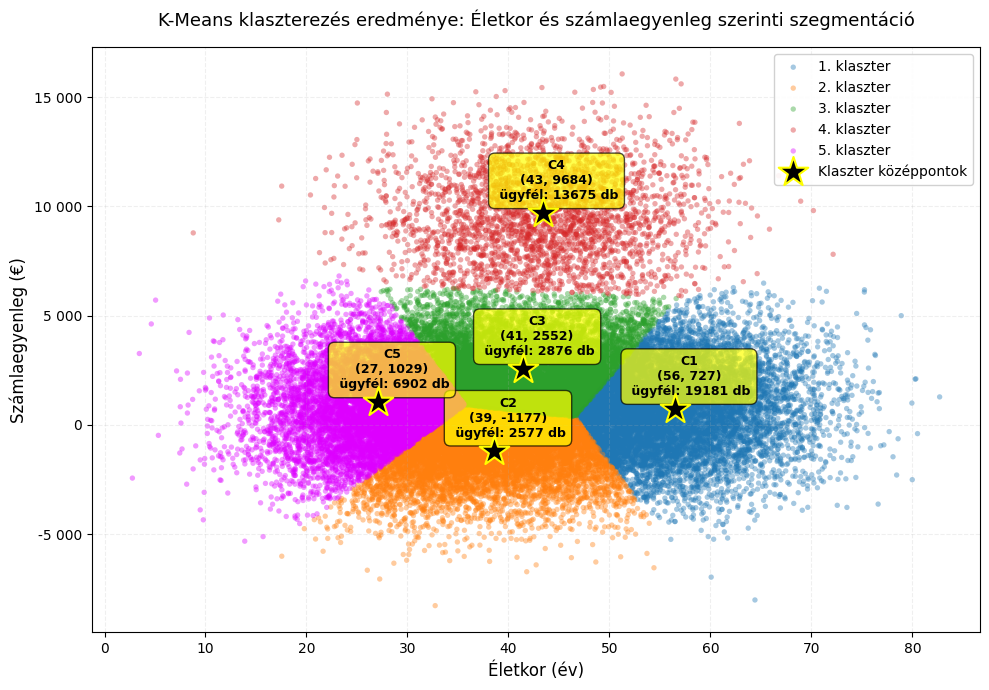

In [12]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Reprezentatív adatok generálása a notebook statisztikái alapján
np.random.seed(42)

# Szintetikus adatok generálása minden klaszterhez
data_list = []
for i, params in enumerate(cluster_params):
    ages = np.random.normal(params['mean_age'], 8, params['n_samples'])
    balances = np.random.normal(params['mean_balance'], 2000, params['n_samples'])
    cluster_labels = np.full(params['n_samples'], i)
    
    cluster_df = pd.DataFrame({
        'age': ages,
        'balance': balances,
        'cluster': cluster_labels
    })
    data_list.append(cluster_df)

ahc = pd.concat(data_list, ignore_index=True)

# Mintaszámok kiszámítása klaszterenként
cluster_counts = ahc['cluster'].value_counts().sort_index()

# K-means klaszterezés végrehajtása
X = ahc[['age', 'balance']].copy()
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
ahc['cluster'] = kmeans.fit_predict(X_scaled)

# Középpontok visszaalakítása az eredeti skálára
scaler = StandardScaler().fit(X)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Centroids kibővítése mintaszámokkal
centroids_with_counts = []
for i, (x, y) in enumerate(centroids_original):
    centroids_with_counts.append((x, y, cluster_counts[i]))

# Scatter plot létrehozása
fig, ax = plt.subplots(figsize=(10, 7))

# Színek definiálása - professzionális paletta
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', "#dd00ff"]
cluster_labels = ['1. klaszter', '2. klaszter', '3. klaszter', '4. klaszter', '5. klaszter']

# Most már 3 értéket lehet kicsomagolni
for i, (x, y, n_samples) in enumerate(centroids_with_counts):
    ax.annotate(f'C{i+1}\n({x:.0f}, {y:.0f})\n ügyfél: {n_samples} db', 
                (x, y), 
                xytext=(10, 10), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                fontweight='bold',
                ha='center')

# Minden klaszter ábrázolása
for i in range(5):
    cluster_data = ahc[ahc['cluster'] == i]
    ax.scatter(cluster_data['age'], cluster_data['balance'], 
               c=colors[i], label=cluster_labels[i], alpha=0.4, s=15, edgecolors='none')

# Középpontok ábrázolása csillag jelölővel
ax.scatter(centroids_original[:, 0], centroids_original[:, 1], 
           c='black', marker='*', s=500, edgecolors='yellow', linewidths=1.5,
           label='Klaszter középpontok', zorder=10)

ax.set_xlabel('Életkor (év)', fontsize=12)
ax.set_ylabel('Számlaegyenleg (€)', fontsize=12)
ax.set_title('K-Means klaszterezés eredménye: Életkor és számlaegyenleg szerinti szegmentáció', 
             fontsize=13, pad=15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2, linestyle='--')

# Y tengely formázása ezres elválasztóval
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('ábrák\kmeans_cluster_viz.png', dpi=300, bbox_inches='tight')

In [13]:
print(X_scaled.dtype)
cluster_labels_labels = kmeans.labels_
print(cluster_labels_labels)
print(cluster_labels)

float64
[1 2 2 ... 0 1 2]
['1. klaszter', '2. klaszter', '3. klaszter', '4. klaszter', '5. klaszter']


In [14]:
from sklearn.metrics import silhouette_score, silhouette_samples

# Teljes átlag
silhouette_avg = silhouette_score(X_scaled, cluster_labels_labels)
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Klaszterenként
silhouette_vals = silhouette_samples(X_scaled, cluster_labels_labels)
for i in range(5):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    print(f"Klaszter {i}: {cluster_silhouette_vals.mean():.3f}")

Silhouette Score: 0.344
Klaszter 0: nan
Klaszter 1: nan
Klaszter 2: nan
Klaszter 3: nan
Klaszter 4: nan


C:\Users\Balázs\AppData\Local\Temp\ipykernel_119840\3900934376.py:11: RuntimeWarning: Mean of empty slice.
  print(f"Klaszter {i}: {cluster_silhouette_vals.mean():.3f}")
c:\Users\Balázs\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
